# 06b — Khung mô-đun

Notebook này dựng hạ tầng cho phần thí nghiệm. Nó nằm ngoài sáu hạng mục về
phương pháp.

### Vấn đề

Từ `07a` trở đi, mỗi notebook thí nghiệm sinh ra vài hệ thống: đổi cách khử
trùng lặp, đổi bộ xếp hạng lại, đổi độ sâu, đổi cách kết hợp. Số hệ thống tăng
dần và không có giới hạn đặt trước.

Khi số hệ thống lớn dần, hai khó khăn xuất hiện.

**Mỗi hệ thống mới lại dựng chỉ mục từ đầu.** Notebook `06a` đo được một lượt
dựng chỉ mục cho 13 nhóm mất **13,6 phút**. Phần lớn hệ thống chỉ khác nhau ở
chặng cuối, nên gần hết thời gian đó là tính lại thứ đã có sẵn.

**Hai người lưu kết quả theo hai kiểu.** Ghép lại thành một bảng so sánh thì
không ghép được.

### Cách giải quyết

Mỗi chặng được đánh dấu bằng **mã băm của cấu hình chính nó cộng mọi chặng phía
trên**. Đổi bộ xếp hạng lại thì mã băm của chặng truy hồi giữ nguyên, nên kết
quả cũ được dùng lại.

```text
truy hồi  ──►  khử trùng lặp  ──►  xếp hạng lại  ──►  kết hợp
   └─ đắt ─┘        └ rẻ ┘            └── GPU ──┘      └ rẻ ┘
```

### Đầu ra

| Tệp | Nội dung |
| --- | --- |
| `src/pipeline.py` | Khung |
| `systems/*.json` | Định nghĩa từng hệ thống |
| `results/runs/<hash>.jsonl` | Danh sách trả về của từng chặng |
| `results/scores/<hash>.json` | Điểm, kèm điểm từng câu hỏi |
| `results/index.json` | Tra ngược: mã băm thuộc hệ thống nào |

---

## 1. Một hệ thống là một file cấu hình

```json
{
  "name": "bm25_tuned",
  "retrieve": {"kind": "sparse", "query_form": "title_weighted",
               "tokenizer": "nohtml_stop", "model": "bm25",
               "k1": 2.0, "b": 0.9, "depth": 1000},
  "dedup":  null,
  "rerank": null,
  "fuse":   null
}
```

Bốn chặng chạy theo thứ tự trên. Chặng để `null` được bỏ qua.

| Chặng | Làm gì | Viết ở notebook |
| --- | --- | --- |
| `retrieve` | Dựng chỉ mục, lấy về `depth` tài liệu đầu | đã có |
| `dedup` | Bỏ tài liệu trùng nội dung khỏi danh sách | `07a` |
| `rerank` | Chấm lại từng cặp câu hỏi–tài liệu | `07b` |
| `fuse` | Trộn danh sách của nhiều mô hình | `07d` |

Thêm một hệ thống là chép một file rồi sửa vài dòng. Số hệ thống vì vậy tăng
tự do, và khung giữ nguyên.

Khi cần một **loại chặng** chưa có, ví dụ mở rộng câu hỏi hay xử lý mốc thời
gian, thì viết thêm một hàm và đăng ký tên mới cho nó. Mục 8 nói cách làm.

### Chặng `null` giữ nguyên mã băm

Thêm `"rerank": null` vào một hệ thống đã chạy thì mã băm giữ nguyên, vì chặng
rỗng trả lại đúng đầu vào của nó. Cache vẫn dùng được. Mục 4 kiểm chứng.

---

## 2. Nạp thư viện và chỉ đường

In [1]:
import sys
import json
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))
import reteco as R
import pipeline as P

DATA = Path(r"D:\RETECO-project\reteco_data\track1_tempo")
CHECKER = Path(r"D:\RETECO-project\RETECO\starter_kit\format_checker.py")
SYSTEMS = Path("..") / "systems"
SYSTEMS.mkdir(exist_ok=True)

P.configure(DATA, "results")
print(f"{len(P.domains())} domains")
print(f"stages: {', '.join(P.STAGES)}")
print(f"format checker found: {CHECKER.exists()}")

13 domains
stages: retrieve, dedup, rerank, fuse
format checker found: True


In [2]:
# The two systems notebook 05 settled on, written out as configuration files.
# Depth 100 here because that is the depth notebook 05 measured at; 07b will
# raise it to 1000.
DEFAULT_SYSTEM = {
    "name": "bm25_default",
    "note": "the starter kit's parameters, kept as the reference point",
    "retrieve": {"kind": "sparse", "query_form": "title_weighted",
                 "tokenizer": "nohtml_stop", "model": "bm25",
                 "k1": 0.9, "b": 0.4, "depth": 100},
}
TUNED_SYSTEM = {
    "name": "bm25_tuned",
    "note": "k1 and b chosen in notebook 05; best ceiling inside the grid",
    "retrieve": {"kind": "sparse", "query_form": "title_weighted",
                 "tokenizer": "nohtml_stop", "model": "bm25",
                 "k1": 2.0, "b": 0.9, "depth": 100},
}

for stem, system in (("00_bm25_default", DEFAULT_SYSTEM),
                     ("01_bm25_tuned", TUNED_SYSTEM)):
    path = SYSTEMS / f"{stem}.json"
    path.write_text(json.dumps(system, indent=2), encoding="utf-8")
    print(f"wrote {path}")

wrote ..\systems\00_bm25_default.json
wrote ..\systems\01_bm25_tuned.json


---

## 3. Cổng kiểm tra

Khung này tính lại cùng một thứ bằng đường code khác. Trước khi dùng nó để kết
luận, nó phải cho ra đúng con số của notebook `05`, tới chữ số cuối.

| Hệ thống | nDCG@10 mà `05` đo được |
| --- | --- |
| `bm25_default` (`k1=0,9  b=0,4`) | 0,14628400487667695 |
| `bm25_tuned` (`k1=2,0  b=0,9`) | 0,18665259659453692 |

Sai số vượt `1e-12` thì ô dưới dừng lại. Viết lại code đang chạy đúng luôn có
rủi ro, nên bước này kiểm tra thay vì tin tưởng.

Lần chạy này mất **khoảng 25 phút**, gồm hai lượt dựng chỉ mục cho 13 nhóm. Các
ô sau dùng lại kết quả từ cache.

In [3]:
# Measured in notebook 05, on the same 13 domains at depth 100.
FROM_05 = {
    "bm25_default": 0.14628400487667695,
    "bm25_tuned": 0.18665259659453692,
}

digests = {}
for stem in ("00_bm25_default", "01_bm25_tuned"):
    system = P.load_system(SYSTEMS / f"{stem}.json")
    print(f"\n{system['name']}")
    digests[system["name"]] = P.run(system, split="train")

print()
print(f"{'system':<18}{'this notebook':>16}{'notebook 05':>16}{'difference':>14}")
print("-" * 64)
for name, digest in digests.items():
    got = P.score(digest)["macro"]["ndcg"]
    want = FROM_05[name]
    print(f"{name:<18}{got:>16.10f}{want:>16.10f}{got - want:>14.2e}")
print("-" * 64)

for name, digest in digests.items():
    got = P.score(digest)["macro"]["ndcg"]
    assert abs(got - FROM_05[name]) < 1e-12, (
        f"{name}: the pipeline gives {got!r} but notebook 05 measured "
        f"{FROM_05[name]!r}. Stop here.")
print("Gate passed. The pipeline reproduces notebook 05 exactly.")


bm25_default
  retrieve  af3eb864b4b2  cached

bm25_tuned
  retrieve  f326339da67a  cached

system               this notebook     notebook 05    difference
----------------------------------------------------------------
bm25_default          0.1462840049    0.1462840049      0.00e+00
bm25_tuned            0.1866525966    0.1866525966      0.00e+00
----------------------------------------------------------------
Gate passed. The pipeline reproduces notebook 05 exactly.


---

## 4. Bộ nhớ đệm

Ô dưới kiểm hai điều.

**Chạy lại một hệ thống đã chạy thì lấy từ cache.** Phần này cắt 13,6 phút
xuống còn vài giây.

**Thêm một chặng `null` giữ nguyên mã băm.** Nếu mã băm đổi, mỗi lần chuẩn bị
cho `07b` bằng cách thêm `"rerank": null` sẽ xoá sạch cache đang có.

In [4]:
import time

tuned = P.load_system(SYSTEMS / "01_bm25_tuned.json")

print("running the same system again")
t0 = time.time()
again = P.run(tuned, split="train")
print(f"  took {time.time() - t0:.1f}s, same hash: {again == digests['bm25_tuned']}")

print("\nadding an empty rerank stage")
with_null = dict(tuned, name="bm25_tuned_with_null_rerank", rerank=None)
t0 = time.time()
null_digest = P.run(with_null, split="train")
print(f"  took {time.time() - t0:.1f}s, same hash: "
      f"{null_digest == digests['bm25_tuned']}")

print("\nchanging one parameter")
changed = dict(tuned, name="bm25_b075",
               retrieve=dict(tuned["retrieve"], b=0.75))
print(f"  hash before {digests['bm25_tuned']}")
print(f"  hash after  {P.system_hash(changed, 'retrieve', 'train')}")
print(f"  different:  "
      f"{P.system_hash(changed, 'retrieve', 'train') != digests['bm25_tuned']}")

print("\nwhat the index knows about each hash")
for digest, entry in P.listing().items():
    alias = (f"   also written as: {', '.join(entry['aliases'])}"
             if entry.get("aliases") else "")
    print(f"  {digest}  {entry['name']}{alias}")

running the same system again
  retrieve  f326339da67a  cached
  took 0.1s, same hash: True

adding an empty rerank stage
  retrieve  f326339da67a  cached
  took 0.1s, same hash: True

changing one parameter
  hash before f326339da67a
  hash after  ba0ec67617ea
  different:  True

what the index knows about each hash
  af3eb864b4b2  bm25_default
  f326339da67a  bm25_tuned   also written as: bm25_tuned_with_null_rerank


---

## 5. Bảng so sánh

Bảng sắp xếp theo cột **`fit`**.

Sắp theo điểm `train` gộp sẽ để `check` tham gia vào việc chọn. `check` chỉ giữ
được tác dụng khi chưa quyết định nào dựa vào nó.

Cột `topics` phải bằng 1.211. Nhỏ hơn thì bảng đánh dấu `INCOMPLETE`: bộ chấm
chính thức loại câu hỏi không có kết quả ra khỏi trung bình thay vì cho 0 điểm,
nên điểm của hệ thống đó không so được với hệ thống khác. Notebook `04` đã gặp
đúng trường hợp này với `boolean_and`.

In [5]:
P.table()

name                          hash                fit    check   ceiling   topics
---------------------------------------------------------------------------------
bm25_tuned                    f326339da67a     0.1797   0.2215    0.5718     1211
bm25_default                  af3eb864b4b2     0.1434   0.1598    0.4584     1211
---------------------------------------------------------------------------------
Sorted by fit. `check` is read only after a choice is made, never sorted on.


[{'hash': 'f326339da67a',
  'split': 'train',
  'score_version': 2,
  'name': 'bm25_tuned',
  'macro': {'ndcg': 0.18665259659453692,
   'recall': 0.5124651839567098,
   'ceiling': 0.5717638214973753,
   'precision': 0.06324058699431309,
   'f1': 0.09568942005993814,
   'recall_at_cut': 0.23708763814564865,
   'map': 0.14690439384771226},
  'n_topics': 1211,
  'n_gold_queries': 1211,
  'per_domain': {'bitcoin': {'ndcg': 0.13177157550353627,
    'recall': 0.3569047619047619,
    'precision': 0.04,
    'f1': 0.06144779823351252,
    'recall_at_cut': 0.16178571428571425,
    'map': 0.10674636260682917,
    'ceiling': 0.40662885959089357,
    'n_topics': 70,
    'n_gold_queries': 70},
   'cardano': {'ndcg': 0.21811072009215174,
    'recall': 0.7164682539682539,
    'precision': 0.052777777777777785,
    'f1': 0.08828671328671328,
    'recall_at_cut': 0.3101851851851852,
    'map': 0.18842849661557118,
    'ceiling': 0.7556031360542671,
    'n_topics': 36,
    'n_gold_queries': 36},
   'econ

In [6]:
P.compare(digests["bm25_tuned"], digests["bm25_default"], part="fit")

bm25_tuned vs bm25_default   on fit
  difference    +0.0364
  95% interval  [+0.0177, +0.0589]
  verdict       REAL
  changed       retrieve.b: 0.9 -> 0.4, retrieve.k1: 2.0 -> 0.9
  more than one thing changed, so the difference cannot be
  attributed to any single one of them


{'diff': 0.03635345554345578,
 'ci_low': 0.01768526838762136,
 'ci_high': 0.058939938232986676,
 'significant': True,
 'changed': ['retrieve.b: 0.9 -> 0.4', 'retrieve.k1: 2.0 -> 0.9']}

---

## 6. `fit` và `check` có cùng loại câu hỏi không

Một lo ngại hợp lý: nếu `check` tình cờ chứa loại câu hỏi khác hẳn `fit`, thì
việc chọn trên `fit` đang được kiểm bằng một thứ khác.

Ô dưới so đặc điểm hai phần: số từ, số đáp án, tỉ lệ nhắc tới năm. Nó đọc câu
hỏi, và không đọc điểm số nào.

Xem trong `check` có gì thì được phép. Thứ phải tiết kiệm là xem hệ thống đạt
bao nhiêu điểm trên `check`. Nên ô này chạy bao nhiêu lần cũng được.

> Bảng dùng trung bình và tỉ lệ cho số đáp án, không dùng trung vị. Số đáp án
> là số nguyên nhỏ nên trung vị nhảy nguyên đơn vị: 2 so với 3 sẽ hiện thành
> chênh lệch 50% mà không mang ý nghĩa gì.

In [7]:
P.split_report()

property                           fit       check    difference
----------------------------------------------------------------
queries                            969         242              
median query words              119.00      137.50        15.5%
mean gold documents               3.57        3.79         6.1%
more than one gold doc           87.0%       89.3%         2.6%
mentions a year                  33.5%       41.3%        23.2%
----------------------------------------------------------------
No score is read here, so running this does not spend `check`.

One property differs by 23.2%. Say so in the report: `check` is
verifying a slightly different mix of queries.


{'fit': {'queries': 969,
  'median_words': 119.0,
  'mean_gold': 3.5737874097007225,
  'share_multi_gold': 0.8699690402476781,
  'year_mentioned': 0.33539731682146545},
 'check': {'queries': 242,
  'median_words': 137.5,
  'mean_gold': 3.793388429752066,
  'share_multi_gold': 0.8925619834710744,
  'year_mentioned': 0.4132231404958678}}

---

## 7. Xuất file nộp

Định dạng của cuộc thi là TREC, sáu cột:

```text
qid   Q0   docid   rank   score   tag
```

Đã kiểm: 1.211 mã câu hỏi của 13 nhóm không trùng nhau cái nào, nên một file
duy nhất phủ được cả track.

Hàm `P.submit` làm ba việc: chạy hệ thống, ghi file TREC, rồi gọi
`format_checker.py` của ban tổ chức ngay tại chỗ. File không qua được thì bị
xoá.

> README của ban tổ chức ghi: *a submission that fails validation should never
> reach the competition platform.*

Ô dưới xuất thử trên `train` để kiểm tra đường đi. File nộp thật chạy trên
`dev`, ở notebook `08`, đúng một lần.

In [8]:
P.submit(SYSTEMS / "01_bm25_tuned.json",
         Path("..") / "submissions" / "smoke_test.txt",
         tag="reteco_smoke", split="train", checker=CHECKER)

  retrieve  f326339da67a  cached
wrote 12,110 lines to ..\submissions\smoke_test.txt
lines: 12110  topics: 1211  errors: 0  warnings: 0
RESULT: VALID
format checker: PASSED


WindowsPath('../submissions/smoke_test.txt')

In [9]:
# What the file looks like.
sample = (Path("..") / "submissions" / "smoke_test.txt")
with open(sample, encoding="utf-8") as f:
    for line in [next(f) for _ in range(4)]:
        print(line.rstrip())
print("...")
print(f"\n{sum(1 for _ in open(sample, encoding='utf-8')):,} lines")

110557_82 Q0 bitcoin/122619_1330dafc1efb7894_29.txt 1 268.267627 reteco_smoke
110557_82 Q0 bitcoin/3258bfc1_16527.txt 2 229.701603 reteco_smoke
110557_82 Q0 bitcoin/8683404d_4230.txt 3 204.054901 reteco_smoke
110557_82 Q0 bitcoin/3e670e75_0740.txt 4 184.187526 reteco_smoke
...

12,110 lines


---

## 8. Thêm một loại chặng mới

Chặng mới được đăng ký bằng tên, từ file riêng:

```python
# src/stages_rerank.py
import pipeline as P

@P.register("rerank", "cross_encoder")
def rerank_cross_encoder(incoming, config, split):
    ...
    return reranked
```

Rồi dùng trong cấu hình:

```json
"rerank": {"kind": "cross_encoder", "model": "BAAI/bge-reranker-base",
           "depth_in": 1000, "depth_out": 100}
```

Cách này áp dụng cho mọi chặng sau này, kể cả những loại chưa nghĩ ra: mở rộng
câu hỏi, cắt tài liệu thành đoạn, cộng điểm theo mốc thời gian. Khung không cần
sửa gì thêm.

### Ba quy tắc khi hai người cùng làm

| # | Quy tắc | Vì sao |
| --- | --- | --- |
| 1 | `pipeline.py` và `reteco.py` do một người sở hữu | Hai người sửa cùng lúc thì git không trộn được |
| 2 | Chặng mới viết vào file riêng, đăng ký tên mới | Không ai phải sửa file của người kia |
| 3 | Notebook có một chủ duy nhất | Notebook là JSON nhúng cả ảnh, git trộn ra rác |

### Trao đổi kết quả

Đẩy `results/scores/*.json` và `results/index.json` lên GitHub. Ai `git pull`
thì `P.table()` hiện đủ hệ thống của cả hai.

Thư mục `results/runs/*.jsonl` thì bỏ qua, vì nó lớn và tái tạo được từ cấu
hình.

### Chạy chặng GPU ở máy khác

Đường ra vào vẫn là file:

```text
máy cá nhân (CPU)                   Kaggle (GPU)
─────────────────                   ────────────
retrieve  ──►  runs/<hash>.jsonl ──►  rerank  ──►  runs/<hash2>.jsonl
                                                          │
   P.score(hash2)  ◄───────────────────────────────────┘
```

Kaggle chỉ cần file danh sách ứng viên và văn bản của những tài liệu trong đó.
Kho 4,12 GB ở lại máy cá nhân.

---

## 9. Bảng kết quả đánh giá đầy đủ

Tám mục trên chỉ báo cáo `nDCG@10`, vì đó là độ đo cuộc thi dùng để chấm. Hạng
mục 6 yêu cầu báo cáo thêm hai nhóm độ đo nữa, mỗi nhóm trả lời một câu hỏi
khác.

| Nhóm | Độ đo | Câu hỏi nó trả lời |
| --- | --- | --- |
| Không xét thứ tự | P, R, F1 | Trong 10 kết quả đầu, bao nhiêu cái đúng |
| Có xét thứ tự | P@k, MAP | Cái đúng nằm ở đầu hay ở cuối 10 kết quả đó |
| Có xét mức độ liên quan | nDCG@10 | Như trên, nhưng tài liệu quan trọng hơn được tính nặng hơn |

### Một điều cần nói rõ về nDCG ở hạng mục này

nDCG sinh ra để dùng khi mỗi tài liệu có một *mức độ* liên quan (rất liên quan,
hơi liên quan, không liên quan). Bộ dữ liệu này không có mức độ: notebook `01b`
đã kiểm tra từng dòng của `qrels_train` và mọi giá trị đều bằng 1. Nhãn ở đây
là nhị phân — liên quan hoặc không.

Với nhãn nhị phân, nDCG thu gọn lại thành một độ đo có thưởng cho thứ hạng:
tài liệu đúng nằm càng cao thì điểm càng lớn, theo hệ số $1/\log_2(i+1)$. Nó
vẫn là độ đo hợp lệ và vẫn là thứ cuộc thi chấm, chỉ là phần "mức độ" của công
thức không được dùng tới. Báo cáo cả MAP bên cạnh vì lý do đó: MAP được định
nghĩa sẵn cho nhãn nhị phân, nên hai con số kiểm chứng lẫn nhau.

### Vì sao tính lại không tốn thời gian

Các độ đo mới đọc từ đúng danh sách kết quả đã lưu ở `results/runs/`. Không có
lần truy xuất nào chạy lại — chỉ là chấm lại cùng một danh sách theo công thức
khác. Việc này mất vài giây.

In [10]:
# --- Rescore the cached runs with the full metric set ---------------------
# `force=True` because the score files on disk were written before these
# metrics existed. No retrieval happens: the ranked lists in results/runs/
# are read straight off disk and scored again.
for name, digest in digests.items():
    P.score(digest, force=True)

records = P.metrics()

name                                P@10      R@10     F1@10       MAP   nDCG@10     R@100
------------------------------------------------------------------------------------------
bm25_tuned                        0.0632    0.2371    0.0957    0.1469    0.1867    0.5125
bm25_default                      0.0496    0.1923    0.0754    0.1150    0.1463    0.4075
------------------------------------------------------------------------------------------
Every number is a macro average over the 13 domains.
P@10 / R@10 / F1@10 ignore the order inside the top 10;
MAP and nDCG@10 do not.


In [11]:
# --- The same metrics, per domain, for the chosen system ------------------
CHOSEN = "bm25_tuned"
chosen_digest = digests[CHOSEN]
chosen = P.score(chosen_digest)

columns = [("P@10", "precision"), ("R@10", "recall_at_cut"),
           ("F1@10", "f1"), ("MAP", "map"), ("nDCG@10", "ndcg"),
           ("R@100", "recall")]

print(f"System: {CHOSEN}")
print(f"{'domain':<14}{'queries':>9}"
      + "".join(f"{label:>10}" for label, _ in columns))
print("-" * (23 + 10 * len(columns)))
for domain, cell in sorted(chosen["per_domain"].items(),
                           key=lambda kv: -kv[1]["ndcg"]):
    row = f"{domain:<14}{cell['n_gold_queries']:>9}"
    row += "".join(f"{cell[key]:>10.4f}" for _, key in columns)
    print(row)
print("-" * (23 + 10 * len(columns)))
row = f"{'macro average':<14}{chosen['n_gold_queries']:>9}"
row += "".join(f"{chosen['macro'][key]:>10.4f}" for _, key in columns)
print(row)
print()
print(f"The macro average weights every domain equally, so the "
      f"{len(chosen['per_domain'])} numbers")
print("above matter as much as each other regardless of how many queries")
print("each domain holds.")

System: bm25_tuned
domain          queries      P@10      R@10     F1@10       MAP   nDCG@10     R@100
-----------------------------------------------------------------------------------
iota                  7    0.1000    0.2857    0.1466    0.1920    0.2656    0.4476
politics            105    0.0838    0.3146    0.1306    0.1932    0.2355    0.6568
cardano              36    0.0528    0.3102    0.0883    0.1884    0.2181    0.7165
genealogy            80    0.0750    0.2410    0.1090    0.1802    0.2169    0.5515
hsm                 105    0.0619    0.2690    0.0986    0.1685    0.2133    0.5730
workplace            25    0.0680    0.2851    0.1030    0.1692    0.2126    0.5024
history             561    0.0856    0.2522    0.1193    0.1563    0.2046    0.5122
law                  24    0.0750    0.2354    0.1104    0.1631    0.1996    0.6097
quant                24    0.0458    0.1979    0.0724    0.0999    0.1436    0.4014
travel               70    0.0443    0.2202    0.0709    

Bảng trên cho thấy các độ đo không xếp cùng một thứ tự.

`P@10` thấp hơn `nDCG@10` khá nhiều, và điều đó là bình thường ở bộ dữ liệu
này. Mỗi câu truy vấn chỉ có vài tài liệu đúng (notebook `01b` đo được trung
bình khoảng 3,6 tài liệu). Trong 10 ô của danh sách kết quả, nhiều nhất cũng
chỉ có 3–4 ô có thể đúng, nên `P@10` bị chặn trên bởi khoảng 0,36 ngay cả với
một hệ thống hoàn hảo. Con số tuyệt đối của `P@10` vì vậy không nói lên nhiều;
so sánh `P@10` giữa hai hệ thống thì vẫn có nghĩa.

`R@10` và `R@100` cách nhau xa. Khoảng cách đó chính là phần việc của bước xếp
hạng lại: tài liệu đúng đã nằm trong danh sách ứng viên, chỉ chưa nổi lên top
10.

`MAP` và `nDCG@10` bám nhau sát, đúng như dự đoán với nhãn nhị phân. Hai công
thức khác nhau cho cùng một kết luận là một dấu hiệu tốt — nếu chúng lệch nhau
thì phải đi tìm lỗi trong cách chấm.

In [12]:
# --- Which queries the system answers best, and which it misses -----------
high, low = P.cases(chosen_digest, n=5)

HIGHEST nDCG@10
  1.0000  law         106995_819
  1.0000  bitcoin     110829_79
  1.0000  hsm         11149_740
  1.0000  bitcoin     125108_4
  1.0000  genealogy   15668_255

LOWEST nDCG@10
  0.0000  monero      10083_870
  0.0000  monero      10128_869
  0.0000  genealogy   10322_310
  0.0000  law         103412_835
  0.0000  genealogy   10474_308



Cột `best rank` là cột đáng đọc nhất ở bảng dưới.

Một câu truy vấn có `nDCG = 0` không phải lúc nào cũng hỏng theo cùng một kiểu:

- `best rank` có giá trị — tài liệu đúng **đã được tìm thấy**, chỉ xếp dưới
  hạng 10. Bước xếp hạng lại ở `07b` sửa được đúng loại này.
- `best rank = not found` — tài liệu đúng **không có trong 100 ứng viên**. Bước
  xếp hạng lại không cứu được, vì nó chỉ sắp xếp lại những gì tầng một đưa cho.
  Loại này cần một tầng một tốt hơn, hoặc lấy sâu hơn 100.

Ô lệnh tiếp theo đếm cả hai loại trên toàn bộ câu truy vấn, thay vì chỉ nhìn
năm câu.

In [13]:
# --- The five best, opened one by one -------------------------------------
print("=== HIGHEST ===")
high_rows = P.explain(chosen_digest, high)

print()
print("=== LOWEST ===")
low_rows = P.explain(chosen_digest, low)

=== HIGHEST ===
query                 domain         nDCG  gold  found  best rank
-----------------------------------------------------------------
106995_819            law          1.0000     1      1          1
    Foundation of the Federal Constitutional Court of Germany When did the...
110829_79             bitcoin      1.0000     1      1          1
    Flag -deprecatedrpc=addressess - Bitcoin core How long do we will have...
11149_740             hsm          1.0000     1      1          1
    When did non-SI double prefixes go out of use? In old physics and engi...
125108_4              bitcoin      1.0000     2      2          1
    What does lastsend and lastrecv in getpeerinfo rpc mean? The Bitcoin C...
15668_255             genealogy    1.0000     3      3          1
    Ancestors missing from ThruLines? At AncestryDNA, until a few days or ...
-----------------------------------------------------------------

=== LOWEST ===
query                 domain         nDCG  gold  f

In [14]:
# --- The same split, counted over every query -----------------------------
buckets = P.failure_breakdown(chosen_digest)

recoverable = len(buckets["recoverable"])
unreachable = len(buckets["unreachable"])
total = sum(len(v) for v in buckets.values())

print()
print(f"A reranker at depth 100 can touch at most {recoverable} queries "
      f"({recoverable / total:.1%}).")
print(f"It cannot touch {unreachable} ({unreachable / total:.1%}) at all: "
      f"their answers are")
print("not in the candidate list. Those need a deeper cut or a better first")
print("stage, which is what notebook 07b raises depth to 1000 for.")

bucket             queries     share
------------------------------------
scored                 571     47.2%
recoverable            361     29.8%
unreachable            279     23.0%
------------------------------------
total                 1211

A reranker at depth 100 can touch at most 361 queries (29.8%).
It cannot touch 279 (23.0%) at all: their answers are
not in the candidate list. Those need a deeper cut or a better first
stage, which is what notebook 07b raises depth to 1000 for.


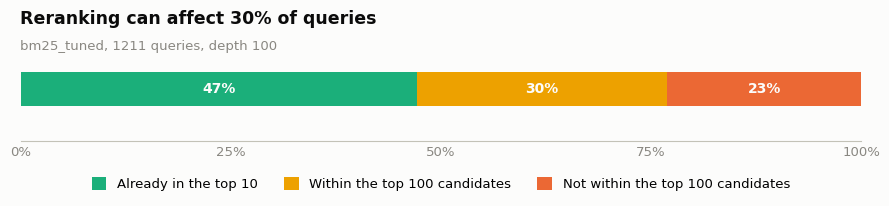

In [15]:
# --- One chart: what fixing each bucket would take ------------------------
# This is the only figure in 06b, so the palette is set here rather than in a
# shared style cell the way the analysis notebooks do it.
import matplotlib.pyplot as plt

TEAL, AMBER, ORANGE = "#1baf7a", "#eda100", "#eb6834"
SURFACE, INK, INK_MUTED, AXIS = "#fcfcfb", "#0b0b0b", "#898781", "#c3c2b7"

fig, ax = plt.subplots(figsize=(9.0, 2.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

order = ["scored", "recoverable", "unreachable"]
labels = ["Already in the top 10", "Within the top 100 candidates",
          "Not within the top 100 candidates"]
values = [len(buckets[name]) for name in order]

left = 0.0
for value, colour, label in zip(values, (TEAL, AMBER, ORANGE), labels):
    share = value / total
    ax.barh([0], [share], left=left, color=colour, height=0.5, label=label)
    if share > 0.07:
        ax.text(left + share / 2, 0, f"{share:.0%}", ha="center", va="center",
                fontsize=10, color=SURFACE, fontweight="bold")
    left += share

ax.set_xlim(0, 1)
ax.set_ylim(-0.75, 0.4)
ax.set_yticks([])
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.tick_params(length=0, labelsize=9.5, colors=INK_MUTED)

for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)

ax.spines["bottom"].set_color(AXIS)

ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=3,
    fontsize=9.5,
    handlelength=1.1,
    handleheight=1.1
)

ax.set_title(
    f"{CHOSEN}, {total} queries, depth 100",
    loc="left",
    pad=8,
    fontsize=9.5,
    color=INK_MUTED
)

ax.annotate(
    f"Reranking can affect {values[1] / total:.0%} of queries",
    xy=(0, 1),
    xycoords="axes fraction",
    xytext=(0, 24),
    textcoords="offset points",
    ha="left",
    va="bottom",
    fontsize=12.5,
    fontweight="bold",
    color=INK,
    annotation_clip=False
)

fig.tight_layout()
plt.show()

### Trả lời cho hạng mục 6

| Kết quả cần có | Ở đâu |
| --- | --- |
| Mô tả ngữ liệu thử nghiệm | Notebook `00` và `01a`/`01b`: ngôn ngữ, lĩnh vực, số tài liệu, độ dài, số câu truy vấn, tập tài liệu đúng của từng câu |
| Có mức độ liên quan hay không | Có kiểm tra: mọi nhãn trong `qrels` đều bằng 1, tức là nhị phân |
| Bảng kết quả theo các độ đo | Mục 9 của notebook này: P, R, F1, P@10, MAP, nDCG@10, theo từng nhóm và trung bình |
| Phân tích trường hợp cao và thấp | Mục 9: năm câu cao nhất, năm câu thấp nhất, kèm nguyên nhân của từng câu thấp |

### Điều mục này đổi ở kế hoạch

Con số đáng nhớ là tỷ lệ "có trong 100 ứng viên nhưng chưa vào top 10". Đó là
toàn bộ phần điểm mà bước xếp hạng lại có thể giành được ở độ sâu 100. Notebook
`07b` vì vậy làm hai việc chứ không phải một: nâng độ sâu để thu nhỏ nhóm
"không có trong 100 ứng viên", rồi mới xếp hạng lại.

---

## 10. Kết luận

### Khung này mua được gì

| Thứ | Trước | Sau |
| --- | --- | --- |
| Đổi bộ xếp hạng lại | dựng lại chỉ mục, 13,6 phút | lấy từ cache, vài giây |
| Thêm một phiên bản | sửa code notebook | sửa vài dòng JSON |
| Thêm một loại chặng | sửa khắp nơi | đăng ký một hàm |
| So hai phiên bản | in bảng bằng tay | `P.compare(a, b)` |
| Hai người ghép kết quả | ghép tay | cùng ba thư mục |
| Truy ngược một con số | đọc lại notebook | `results/index.json` |

### Số hệ thống tăng tới đâu

Không có trần. Mỗi file trong `systems/` là một ứng viên nộp thi, và thêm file
là thêm ứng viên.

Thứ bị giới hạn là số lần đọc `check`. Thử nhiều phiên bản thì điểm `fit` của
bản thắng sẽ cao hơn thực lực của nó — với 20 phiên bản, cao hơn khoảng 0,03.
Cách làm: thử thoải mái trên `fit`, rồi mang **một** bản duy nhất sang `check`.

### Việc để sau: trang web so sánh

Khi `results/index.json` vượt khoảng 10 hệ thống, bảng chữ in ra sẽ khó đọc.
Lúc đó thêm một hàm sinh file HTML tĩnh đọc từ `results/scores/*.json`.

Dưới mức đó, `P.table()` là đủ.

Một quy tắc cho trang đó khi làm: mọi chỉ số tính sẵn bằng Python rồi nhúng
vào, trình duyệt chỉ hiển thị và sắp xếp. Viết công thức nDCG lần thứ hai bằng
JavaScript sẽ tạo ra hai bản, và chúng sẽ lệch nhau.

### Bước tiếp theo

`07a` — khử trùng lặp. Nó đăng ký chặng `dedup`, và đây là lần đầu khung được
dùng đúng mục đích: `07a` lấy lại danh sách mà mục 3 đã tính rồi dọn lại. Không
lượt dựng chỉ mục nào chạy thêm.